# Wstępna analiza statystyczna: dane Reddit (stocks)

Ten notebook zawiera wstępną analizę szeregu dziennego z pliku `stock-reddit-data.csv`:
- wczytanie i walidację danych,
- kontrolę jakości danych (braki, dni zerowej aktywności),
- statystyki opisowe dla aktywności i sentymentu,
- wizualizacje trendów czasowych, rozkładów i wzorców sezonowych,
- diagnostykę autokorelacji i kontrolę zmiennych pochodnych.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10


In [2]:
data_candidates = [
    Path("../data/equity_data/stock-reddit-data.csv"),
    Path("data/equity_data/stock-reddit-data.csv"),
]

data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Nie znaleziono pliku stock-reddit-data.csv z bieżącego katalogu roboczego.")

df = pd.read_csv(data_path)

date_col = "date" if "date" in df.columns else ("Date" if "Date" in df.columns else None)
if date_col is None:
    raise ValueError("Nie znaleziono kolumny z datą. Oczekiwano `date` lub `Date`.")

if date_col != "date":
    df = df.rename(columns={date_col: "date"})

df["date"] = pd.to_datetime(df["date"], errors="coerce")
numeric_cols = [c for c in df.columns if c != "date"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values("date").reset_index(drop=True)

activity_pref = [
    "reddit_posts",
    "reddit_weight_sum",
    "reddit_score_sum",
    "reddit_comments_sum",
]
sentiment_pref = [
    "reddit_vader_mean",
    "reddit_vader_sum",
    "reddit_vader_std",
    "reddit_finbert_mean",
    "reddit_finbert_sum",
    "reddit_finbert_std",
    "reddit_vader_weighted_mean",
    "reddit_finbert_weighted_mean",
    "reddit_sent_mean",
    "reddit_sent_sum",
    "reddit_sent_std",
]

activity_cols = [c for c in activity_pref if c in df.columns]
sentiment_cols = [c for c in sentiment_pref if c in df.columns]
mean_cols = [c for c in sentiment_cols if c.endswith("_mean")]
sum_cols = [c for c in sentiment_cols if c.endswith("_sum")]
std_cols = [c for c in sentiment_cols if c.endswith("_std")]
weighted_mean_cols = [c for c in sentiment_cols if "weighted_mean" in c]

derived_cols = [c for c in ["reddit_sent_mean", "reddit_sent_sum", "reddit_sent_std"] if c in df.columns]
original_cols = [c for c in numeric_cols if c not in derived_cols]

active_mask = (
    df["reddit_posts"].fillna(0) > 0
    if "reddit_posts" in df.columns
    else pd.Series(True, index=df.index)
)

label_map = {
    "reddit_posts": "Liczba postów",
    "reddit_weight_sum": "Suma wag postów",
    "reddit_score_sum": "Suma punktów (score)",
    "reddit_comments_sum": "Suma komentarzy",
    "reddit_vader_mean": "Średni sentyment VADER",
    "reddit_vader_sum": "Suma sentymentu VADER",
    "reddit_vader_std": "Odchylenie sentymentu VADER",
    "reddit_finbert_mean": "Średni sentyment FinBERT",
    "reddit_finbert_sum": "Suma sentymentu FinBERT",
    "reddit_finbert_std": "Odchylenie sentymentu FinBERT",
    "reddit_vader_weighted_mean": "Ważona średnia sentymentu VADER",
    "reddit_finbert_weighted_mean": "Ważona średnia sentymentu FinBERT",
    "reddit_sent_mean": "Średni sentyment łączny",
    "reddit_sent_sum": "Suma sentymentu łącznego",
    "reddit_sent_std": "Odchylenie sentymentu łącznego",
}

print(f"Źródło danych: {data_path}")
print(f"Liczba wierszy: {len(df):,}, liczba kolumn: {len(df.columns)}")
print(f"Zmienne aktywności: {activity_cols}")
print(f"Zmienne sentymentu: {sentiment_cols}")
print(f"Zmienne oryginalne: {original_cols}")
print(f"Zmienne pochodne: {derived_cols}")
display(df.head())


Źródło danych: ..\data\equity_data\stock-reddit-data.csv
Liczba wierszy: 1,095, liczba kolumn: 16
Zmienne aktywności: ['reddit_posts', 'reddit_weight_sum', 'reddit_score_sum', 'reddit_comments_sum']
Zmienne sentymentu: ['reddit_vader_mean', 'reddit_vader_sum', 'reddit_vader_std', 'reddit_finbert_mean', 'reddit_finbert_sum', 'reddit_finbert_std', 'reddit_vader_weighted_mean', 'reddit_finbert_weighted_mean', 'reddit_sent_mean', 'reddit_sent_sum', 'reddit_sent_std']
Zmienne oryginalne: ['reddit_posts', 'reddit_weight_sum', 'reddit_score_sum', 'reddit_comments_sum', 'reddit_vader_mean', 'reddit_vader_sum', 'reddit_vader_std', 'reddit_finbert_mean', 'reddit_finbert_sum', 'reddit_finbert_std', 'reddit_vader_weighted_mean', 'reddit_finbert_weighted_mean']
Zmienne pochodne: ['reddit_sent_mean', 'reddit_sent_sum', 'reddit_sent_std']


,date,reddit_posts,reddit_weight_sum,reddit_score_sum,reddit_comments_sum,reddit_vader_mean,reddit_vader_sum,reddit_vader_std,reddit_finbert_mean,reddit_finbert_sum,reddit_finbert_std,reddit_vader_weighted_mean,reddit_finbert_weighted_mean,reddit_sent_mean,reddit_sent_sum,reddit_sent_std
0,2023-01-01,0,0.000000,0.0,0.0,NaN,0.0000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.0000,NaN
1,2023-01-02,0,0.000000,0.0,0.0,NaN,0.0000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.0000,NaN
2,2023-01-03,20,119.632992,2242.0,1245.0,0.245815,4.9163,0.527104,-0.177089,-3.541777,0.492576,0.305369,-0.175264,0.245815,4.9163,0.527104
3,2023-01-04,5,22.539669,17.0,222.0,0.584260,2.9213,0.533557,-0.430962,-2.154811,0.790026,0.596288,-0.384605,0.584260,2.9213,0.533557
4,2023-01-05,6,38.483158,2247.0,208.0,0.146533,0.8792,0.358442,-0.588133,-3.528797,0.417555,0.258447,-0.780263,0.146533,0.8792,0.358442


In [3]:
quality_report = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(dropna=True),
    }
)

zero_pct = {col: (df[col] == 0).mean() * 100 for col in numeric_cols}
quality_report["zero_pct"] = pd.Series(zero_pct).round(2)
quality_report.loc["date", "zero_pct"] = np.nan

date_range = (df["date"].min(), df["date"].max())
duplicate_rows = int(df.duplicated().sum())
duplicate_dates = int(df["date"].duplicated().sum())

full_calendar = pd.date_range(start=date_range[0], end=date_range[1], freq="D")
missing_dates = full_calendar.difference(df["date"].dropna())

posts_zero_days = int((df["reddit_posts"].fillna(0) == 0).sum()) if "reddit_posts" in df.columns else np.nan
posts_zero_pct = (posts_zero_days / len(df) * 100) if "reddit_posts" in df.columns else np.nan
active_days = int(active_mask.sum())

display(quality_report)
print(f"Zakres dat: {date_range[0].date()} -> {date_range[1].date()}")
print(f"Zduplikowane wiersze: {duplicate_rows}")
print(f"Zduplikowane daty: {duplicate_dates}")
print(f"Brakujące dni kalendarzowe: {len(missing_dates)}")
print(f"Dni bez postów (reddit_posts = 0): {posts_zero_days} ({posts_zero_pct:.2f}%)")
print(f"Dni z aktywnością (reddit_posts > 0): {active_days} ({active_days / len(df) * 100:.2f}%)")

if len(missing_dates) > 0:
    print("Pierwsze brakujące daty:", [d.date() for d in missing_dates[:10]])


,dtype,missing_values,missing_pct,unique_values,zero_pct
date,datetime64[us],0,0.00,1095,NaN
reddit_posts,int64,0,0.00,26,37.53
reddit_weight_sum,float64,0,0.00,632,37.53
reddit_score_sum,float64,0,0.00,385,38.08
reddit_comments_sum,float64,0,0.00,414,40.18
reddit_vader_mean,float64,411,37.53,661,2.01
reddit_vader_sum,float64,0,0.00,660,39.54
reddit_vader_std,float64,509,46.48,578,0.64
reddit_finbert_mean,float64,411,37.53,684,0.00
reddit_finbert_sum,float64,0,0.00,685,37.53


Zakres dat: 2023-01-01 -> 2025-12-30
Zduplikowane wiersze: 0
Zduplikowane daty: 0
Brakujące dni kalendarzowe: 0
Dni bez postów (reddit_posts = 0): 411 (37.53%)
Dni z aktywnością (reddit_posts > 0): 684 (62.47%)


In [4]:
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

def unique_order(values):
    return list(dict.fromkeys(values))

def summarize(columns, frame=df):
    if len(columns) == 0:
        return pd.DataFrame()
    base_stats = frame[columns].describe(percentiles=percentiles).T
    extra_stats = pd.DataFrame(
        {
            "variance": frame[columns].var(),
            "IQR": frame[columns].quantile(0.75) - frame[columns].quantile(0.25),
            "skewness": frame[columns].skew(),
            "kurtosis": frame[columns].kurt(),
            "coef_of_variation": frame[columns].std() / frame[columns].mean().replace(0, np.nan),
        }
    )
    return base_stats.join(extra_stats).round(4)

if len(activity_cols) > 0:
    print("Statystyki opisowe: metryki aktywności (wszystkie dni)")
    display(summarize(activity_cols))

active_df = df.loc[active_mask].copy()
sentiment_summary_cols = unique_order(mean_cols + std_cols + weighted_mean_cols)

if len(sentiment_summary_cols) > 0:
    print("Statystyki opisowe: metryki sentymentu (tylko dni z reddit_posts > 0)")
    display(summarize(sentiment_summary_cols, frame=active_df))

if len(sum_cols) > 0:
    print("Statystyki opisowe: metryki sum sentymentu (wszystkie dni)")
    display(summarize(sum_cols))


Statystyki opisowe: metryki aktywności (wszystkie dni)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,variance,IQR,skewness,kurtosis,coef_of_variation
reddit_posts,1095.0,3.1105,4.4569,0.0,0.0,0.0,0.0,2.000,4.0000,11.0000,18.1200,55.0000,1.986440e+01,4.0000,3.5902,25.1266,1.4329
reddit_weight_sum,1095.0,16.9725,25.7247,0.0,0.0,0.0,0.0,7.743,23.9618,62.8191,116.9686,360.7635,6.617613e+02,23.9618,4.0066,33.9026,1.5157
reddit_score_sum,1095.0,622.8256,2325.4681,0.0,0.0,0.0,0.0,3.000,309.5000,2822.8000,12646.0000,30877.0000,5.407802e+06,309.5000,7.7452,73.8040,3.7337
reddit_comments_sum,1095.0,212.7717,458.1015,0.0,0.0,0.0,0.0,23.000,243.0000,898.6000,2010.5200,7685.0000,2.098570e+05,243.0000,6.5116,76.7613,2.1530


Statystyki opisowe: metryki sentymentu (tylko dni z reddit_posts > 0)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,variance,IQR,skewness,kurtosis,coef_of_variation
reddit_vader_mean,684.0,0.3649,0.3680,-0.9784,-0.6357,-0.2050,0.1271,0.3480,0.6136,0.9572,0.9927,0.9982,0.1354,0.4865,-0.3163,0.2614,1.0083
reddit_finbert_mean,684.0,-0.1382,0.2611,-0.9630,-0.9272,-0.5421,-0.2916,-0.1174,0.0174,0.2751,0.5808,0.9171,0.0682,0.3090,0.0254,1.6764,-1.8891
reddit_vader_weighted_mean,684.0,0.4073,0.4176,-0.9784,-0.6815,-0.3499,0.1194,0.4633,0.7534,0.9581,0.9927,0.9982,0.1744,0.6340,-0.6532,-0.1081,1.0252
reddit_finbert_weighted_mean,684.0,-0.1679,0.3106,-0.9630,-0.9314,-0.7121,-0.3791,-0.1288,0.0258,0.3022,0.6896,0.9171,0.0965,0.4049,-0.0169,0.4549,-1.8496
reddit_sent_mean,684.0,0.3649,0.3680,-0.9784,-0.6357,-0.2050,0.1271,0.3480,0.6136,0.9572,0.9927,0.9982,0.1354,0.4865,-0.3163,0.2614,1.0083
reddit_vader_std,586.0,0.5268,0.2561,0.0000,0.0000,0.0536,0.4010,0.5351,0.6769,0.9387,1.2396,1.3816,0.0656,0.2759,0.0974,0.5626,0.4862
reddit_finbert_std,586.0,0.3636,0.2004,0.0000,0.0110,0.0446,0.2040,0.3782,0.4920,0.6818,0.8944,1.2639,0.0402,0.2880,0.4169,0.7812,0.5511
reddit_sent_std,586.0,0.5268,0.2561,0.0000,0.0000,0.0536,0.4010,0.5351,0.6769,0.9387,1.2396,1.3816,0.0656,0.2759,0.0974,0.5626,0.4862


Statystyki opisowe: metryki sum sentymentu (wszystkie dni)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,variance,IQR,skewness,kurtosis,coef_of_variation
reddit_vader_sum,1095.0,0.9393,1.5631,-4.0929,-1.5696,-0.4042,0.0000,0.2495,1.6464,3.8734,6.1479,15.4032,2.4432,1.6464,2.2755,10.8472,1.6641
reddit_finbert_sum,1095.0,-0.5456,1.4107,-19.1855,-6.4621,-2.9297,-0.8126,0.0000,0.0000,0.5445,1.2131,2.2895,1.9901,0.8126,-4.5396,37.1669,-2.5858
reddit_sent_sum,1095.0,0.9393,1.5631,-4.0929,-1.5696,-0.4042,0.0000,0.2495,1.6464,3.8734,6.1479,15.4032,2.4432,1.6464,2.2755,10.8472,1.6641


,reddit_posts,reddit_weight_sum,reddit_score_sum,reddit_comments_sum,reddit_vader_mean,reddit_vader_sum,reddit_vader_std,reddit_finbert_mean,reddit_finbert_sum,reddit_finbert_std,reddit_vader_weighted_mean,reddit_finbert_weighted_mean,reddit_sent_mean,reddit_sent_sum,reddit_sent_std
reddit_posts,1.0000,0.9585,0.6198,0.7679,-0.1799,0.5881,0.1077,-0.1498,-0.7517,0.1142,-0.1407,-0.1697,-0.1799,0.5881,0.1077
reddit_weight_sum,0.9585,1.0000,0.6914,0.8548,-0.1473,0.5892,0.1373,-0.1886,-0.7709,0.1702,-0.1292,-0.2146,-0.1473,0.5892,0.1373
reddit_score_sum,0.6198,0.6914,1.0000,0.7980,-0.1526,0.2046,0.0823,-0.1792,-0.6506,0.1237,-0.1519,-0.2107,-0.1526,0.2046,0.0823
reddit_comments_sum,0.7679,0.8548,0.7980,1.0000,-0.1443,0.4170,0.1077,-0.1741,-0.6698,0.1396,-0.1255,-0.1964,-0.1443,0.4170,0.1077
reddit_vader_mean,-0.1799,-0.1473,-0.1526,-0.1443,1.0000,0.5078,-0.4951,0.3752,0.2939,-0.0881,0.9300,0.3738,1.0000,0.5078,-0.4951
reddit_vader_sum,0.5881,0.5892,0.2046,0.4170,0.5078,1.0000,-0.2229,0.1599,-0.2113,0.0213,0.5308,0.1688,0.5078,1.0000,-0.2229
reddit_vader_std,0.1077,0.1373,0.0823,0.1077,-0.4951,-0.2229,1.0000,-0.2539,-0.1793,0.1546,-0.4805,-0.2225,-0.4951,-0.2229,1.0000
reddit_finbert_mean,-0.1498,-0.1886,-0.1792,-0.1741,0.3752,0.1599,-0.2539,1.0000,0.5754,-0.2350,0.3785,0.9380,0.3752,0.1599,-0.2539
reddit_finbert_sum,-0.7517,-0.7709,-0.6506,-0.6698,0.2939,-0.2113,-0.1793,0.5754,1.0000,-0.1887,0.2922,0.5784,0.2939,-0.2113,-0.1793
reddit_finbert_std,0.1142,0.1702,0.1237,0.1396,-0.0881,0.0213,0.1546,-0.2350,-0.1887,1.0000,-0.1243,-0.2977,-0.0881,0.0213,0.1546


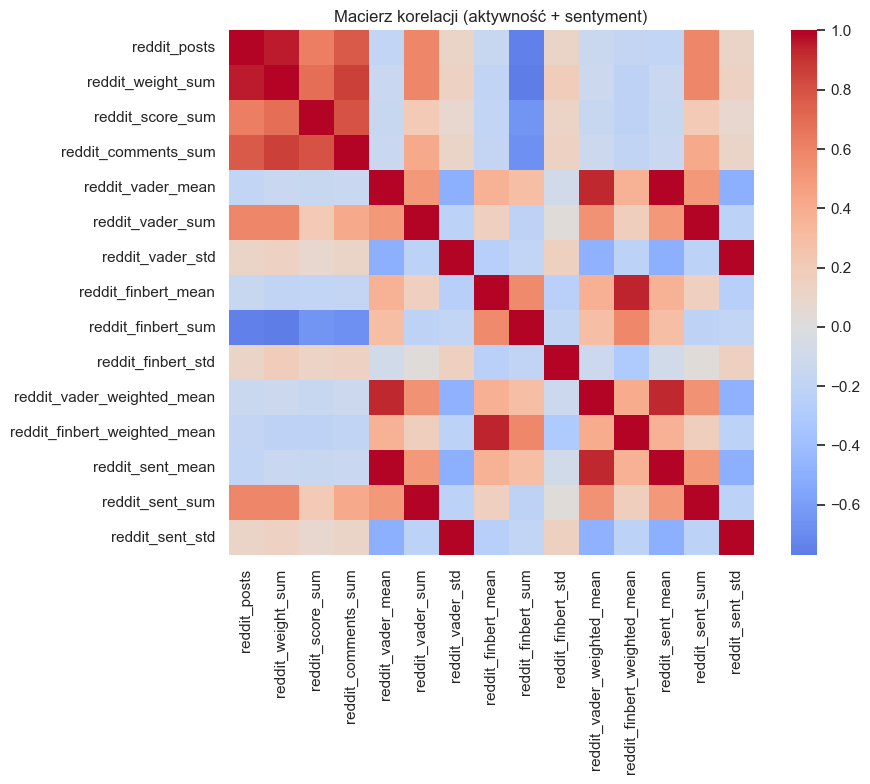

Kontrola spójności potencjalnie pochodnych metryk `reddit_sent_*`:


,maks_abs_różnica,średnia_abs_różnica
porównanie,,
reddit_vader_mean vs reddit_sent_mean,0.0,0.0
reddit_vader_sum vs reddit_sent_sum,0.0,0.0
reddit_vader_std vs reddit_sent_std,0.0,0.0


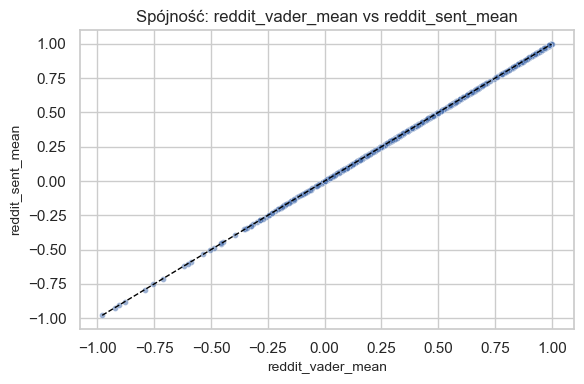

In [5]:
corr_cols = [c for c in unique_order(activity_cols + sentiment_cols) if c in df.columns]
corr = df[corr_cols].corr(method="pearson") if len(corr_cols) > 1 else pd.DataFrame()

if not corr.empty:
    display(corr.round(4))
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, square=True)
    plt.title("Macierz korelacji (aktywność + sentyment)")
    plt.tight_layout()
    plt.show()

consistency_rows = []
for left, right in [
    ("reddit_vader_mean", "reddit_sent_mean"),
    ("reddit_vader_sum", "reddit_sent_sum"),
    ("reddit_vader_std", "reddit_sent_std"),
]:
    if {left, right}.issubset(df.columns):
        diff = (df[left] - df[right]).abs()
        consistency_rows.append(
            {
                "porównanie": f"{left} vs {right}",
                "maks_abs_różnica": diff.max(),
                "średnia_abs_różnica": diff.mean(),
            }
        )

if len(consistency_rows) > 0:
    consistency_df = pd.DataFrame(consistency_rows).set_index("porównanie")
    print("Kontrola spójności potencjalnie pochodnych metryk `reddit_sent_*`:")
    display(consistency_df.round(8))

    if {"reddit_vader_mean", "reddit_sent_mean"}.issubset(df.columns):
        plt.figure(figsize=(6, 4))
        sns.scatterplot(data=df, x="reddit_vader_mean", y="reddit_sent_mean", s=18, alpha=0.55)
        lo = np.nanmin([df["reddit_vader_mean"].min(), df["reddit_sent_mean"].min()])
        hi = np.nanmax([df["reddit_vader_mean"].max(), df["reddit_sent_mean"].max()])
        plt.plot([lo, hi], [lo, hi], color="black", linewidth=1, linestyle="--")
        plt.title("Spójność: reddit_vader_mean vs reddit_sent_mean")
        plt.xlabel("reddit_vader_mean")
        plt.ylabel("reddit_sent_mean")
        plt.tight_layout()
        plt.show()


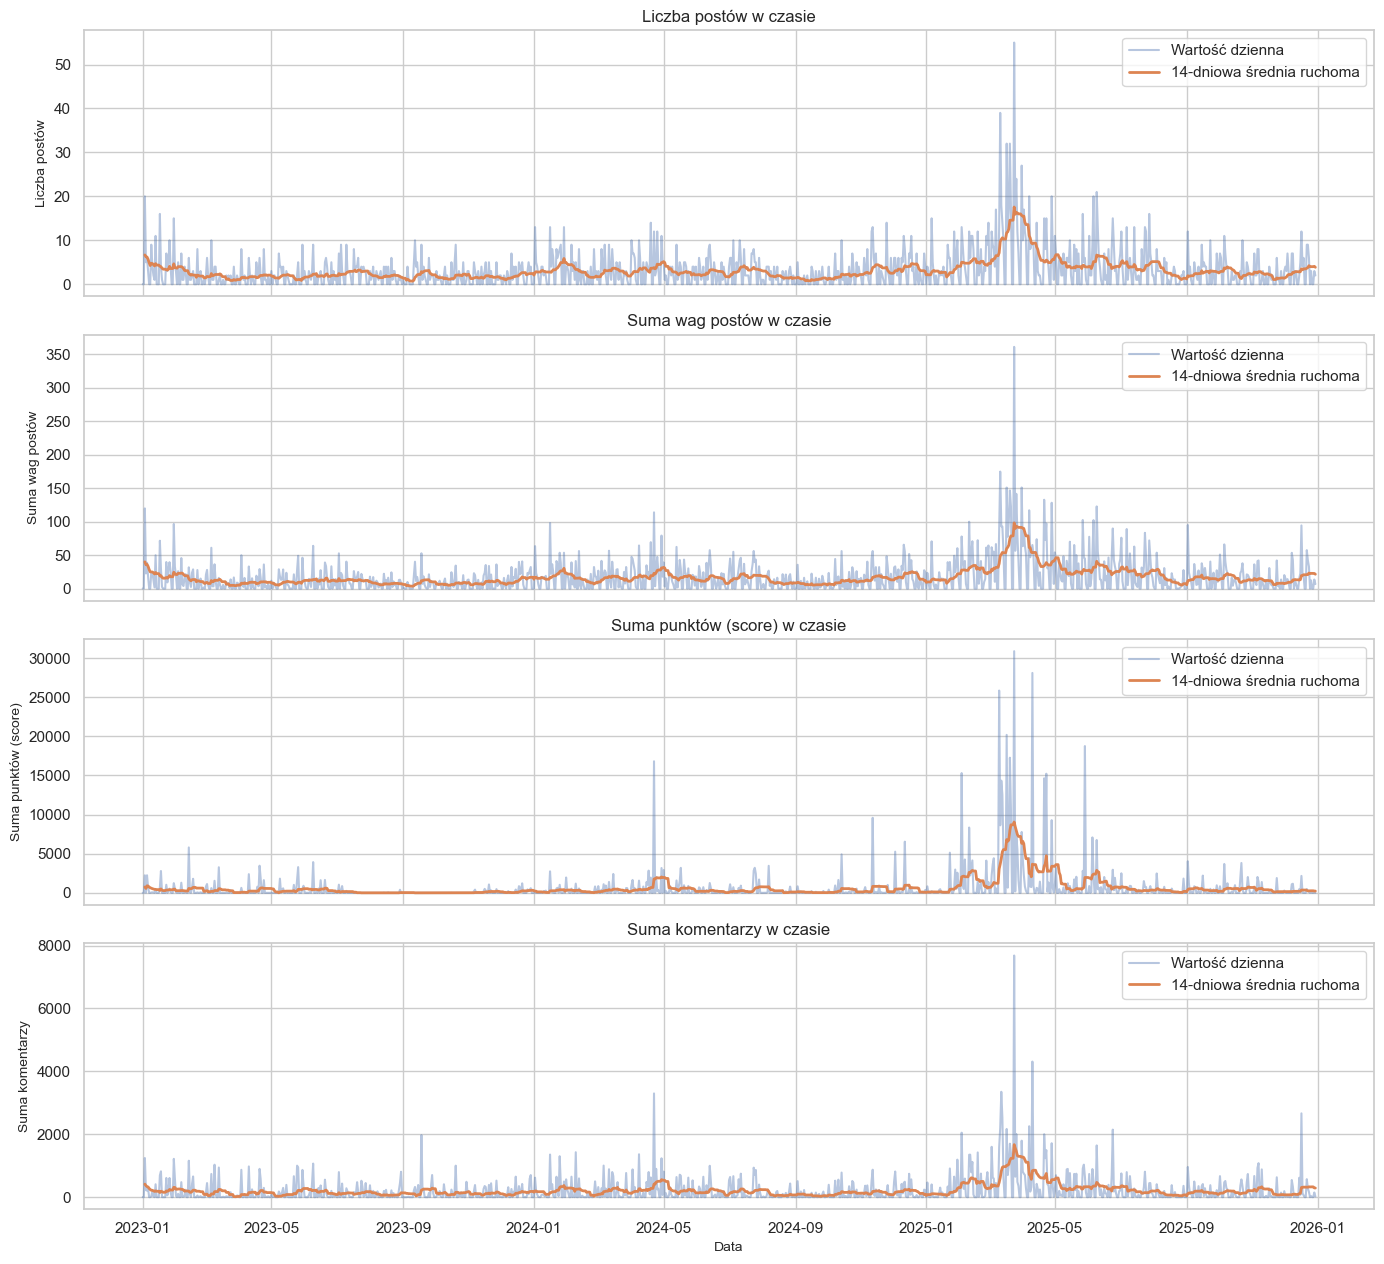

In [6]:
rolling_window = 14

if len(activity_cols) > 0:
    rolling_means = df[activity_cols].rolling(rolling_window, min_periods=3).mean()

    n = len(activity_cols)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.2 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for i, col in enumerate(activity_cols):
        ax = axes[i]
        display_name = label_map.get(col, col)
        ax.plot(df["date"], df[col], alpha=0.4, label="Wartość dzienna")
        ax.plot(
            df["date"],
            rolling_means[col],
            linewidth=2,
            label=f"{rolling_window}-dniowa średnia ruchoma",
        )
        ax.set_title(f"{display_name} w czasie")
        ax.set_ylabel(display_name)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Data")
    plt.tight_layout()
    plt.show()


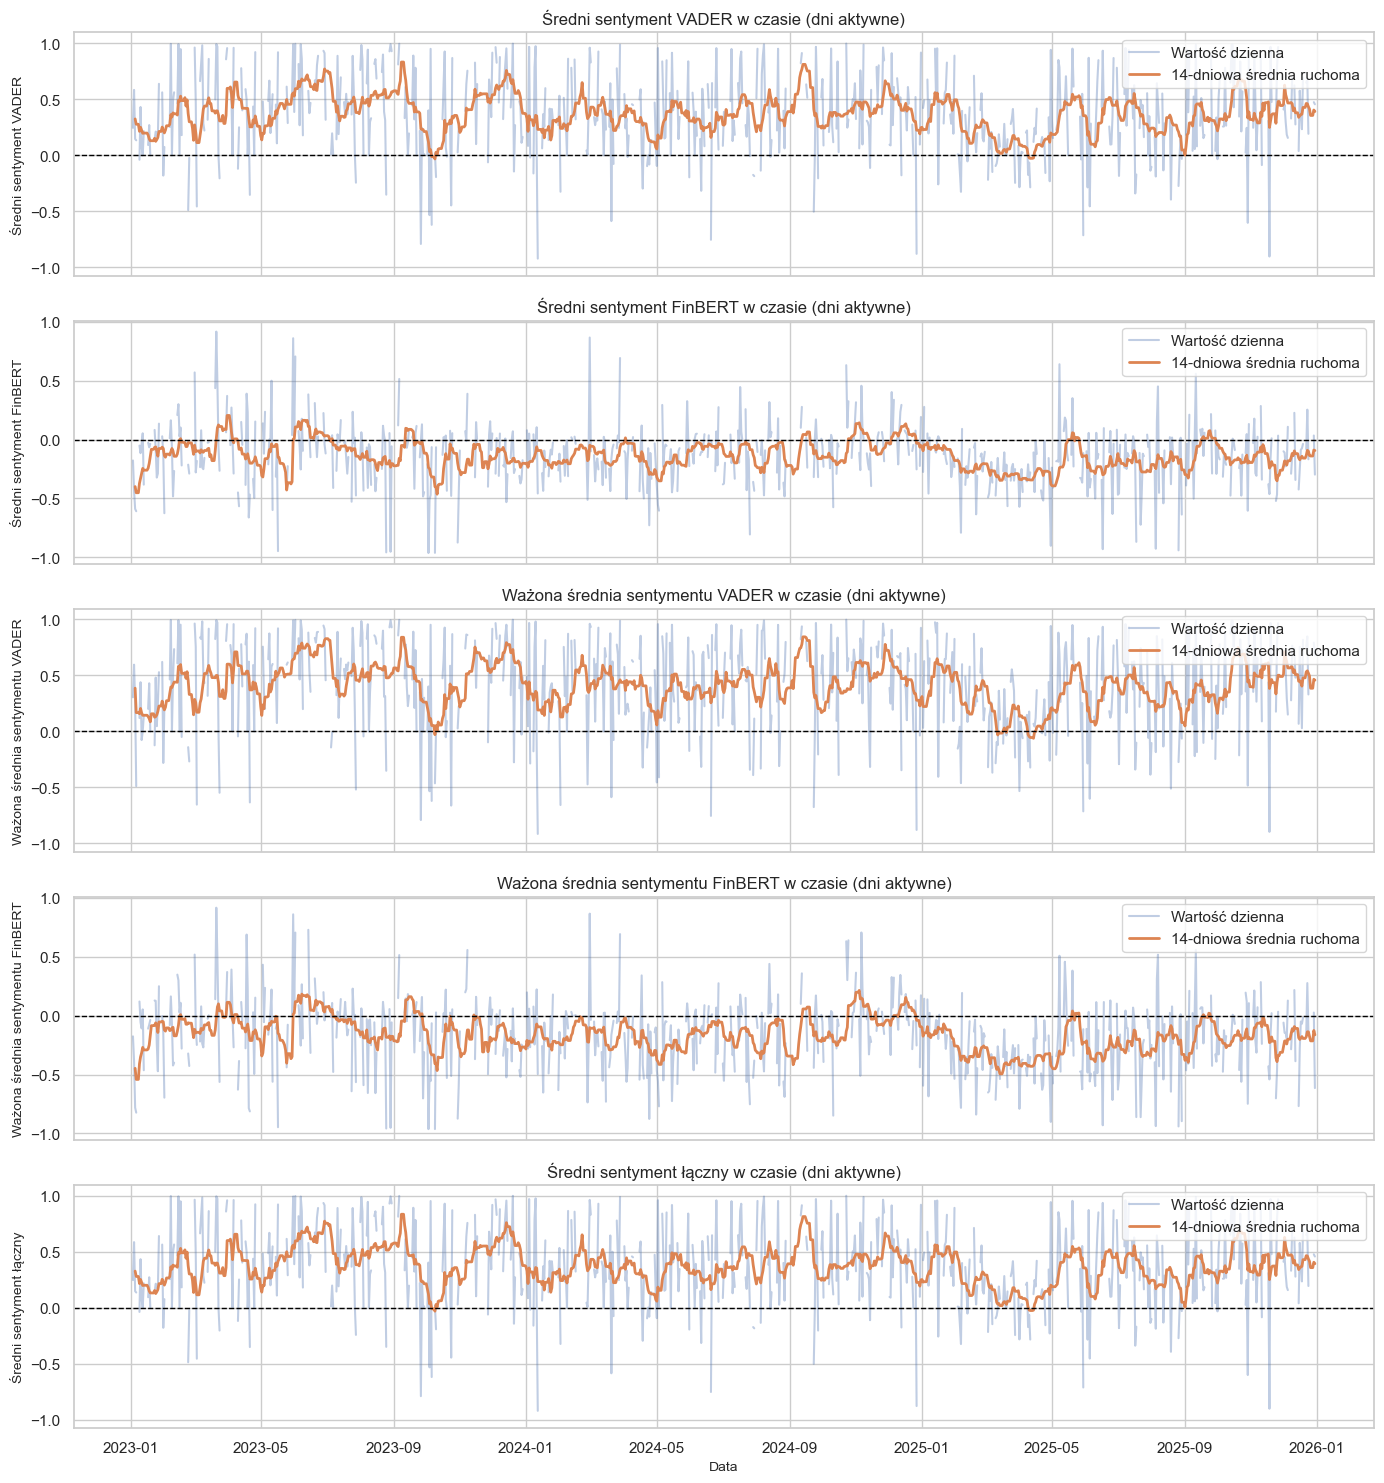

In [7]:
sentiment_trend_cols = [
    c
    for c in [
        "reddit_vader_mean",
        "reddit_finbert_mean",
        "reddit_vader_weighted_mean",
        "reddit_finbert_weighted_mean",
        "reddit_sent_mean",
    ]
    if c in df.columns
]

if len(sentiment_trend_cols) > 0:
    sentiment_plot_df = df[["date"] + sentiment_trend_cols].copy()
    sentiment_plot_df.loc[~active_mask, sentiment_trend_cols] = np.nan
    sentiment_rolling = sentiment_plot_df[sentiment_trend_cols].rolling(rolling_window, min_periods=3).mean()

    n = len(sentiment_trend_cols)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.0 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for i, col in enumerate(sentiment_trend_cols):
        ax = axes[i]
        display_name = label_map.get(col, col)
        ax.plot(sentiment_plot_df["date"], sentiment_plot_df[col], alpha=0.35, label="Wartość dzienna")
        ax.plot(
            sentiment_plot_df["date"],
            sentiment_rolling[col],
            linewidth=2,
            label=f"{rolling_window}-dniowa średnia ruchoma",
        )
        ax.axhline(0, color="black", linewidth=1, linestyle="--")
        ax.set_title(f"{display_name} w czasie (dni aktywne)")
        ax.set_ylabel(display_name)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Data")
    plt.tight_layout()
    plt.show()


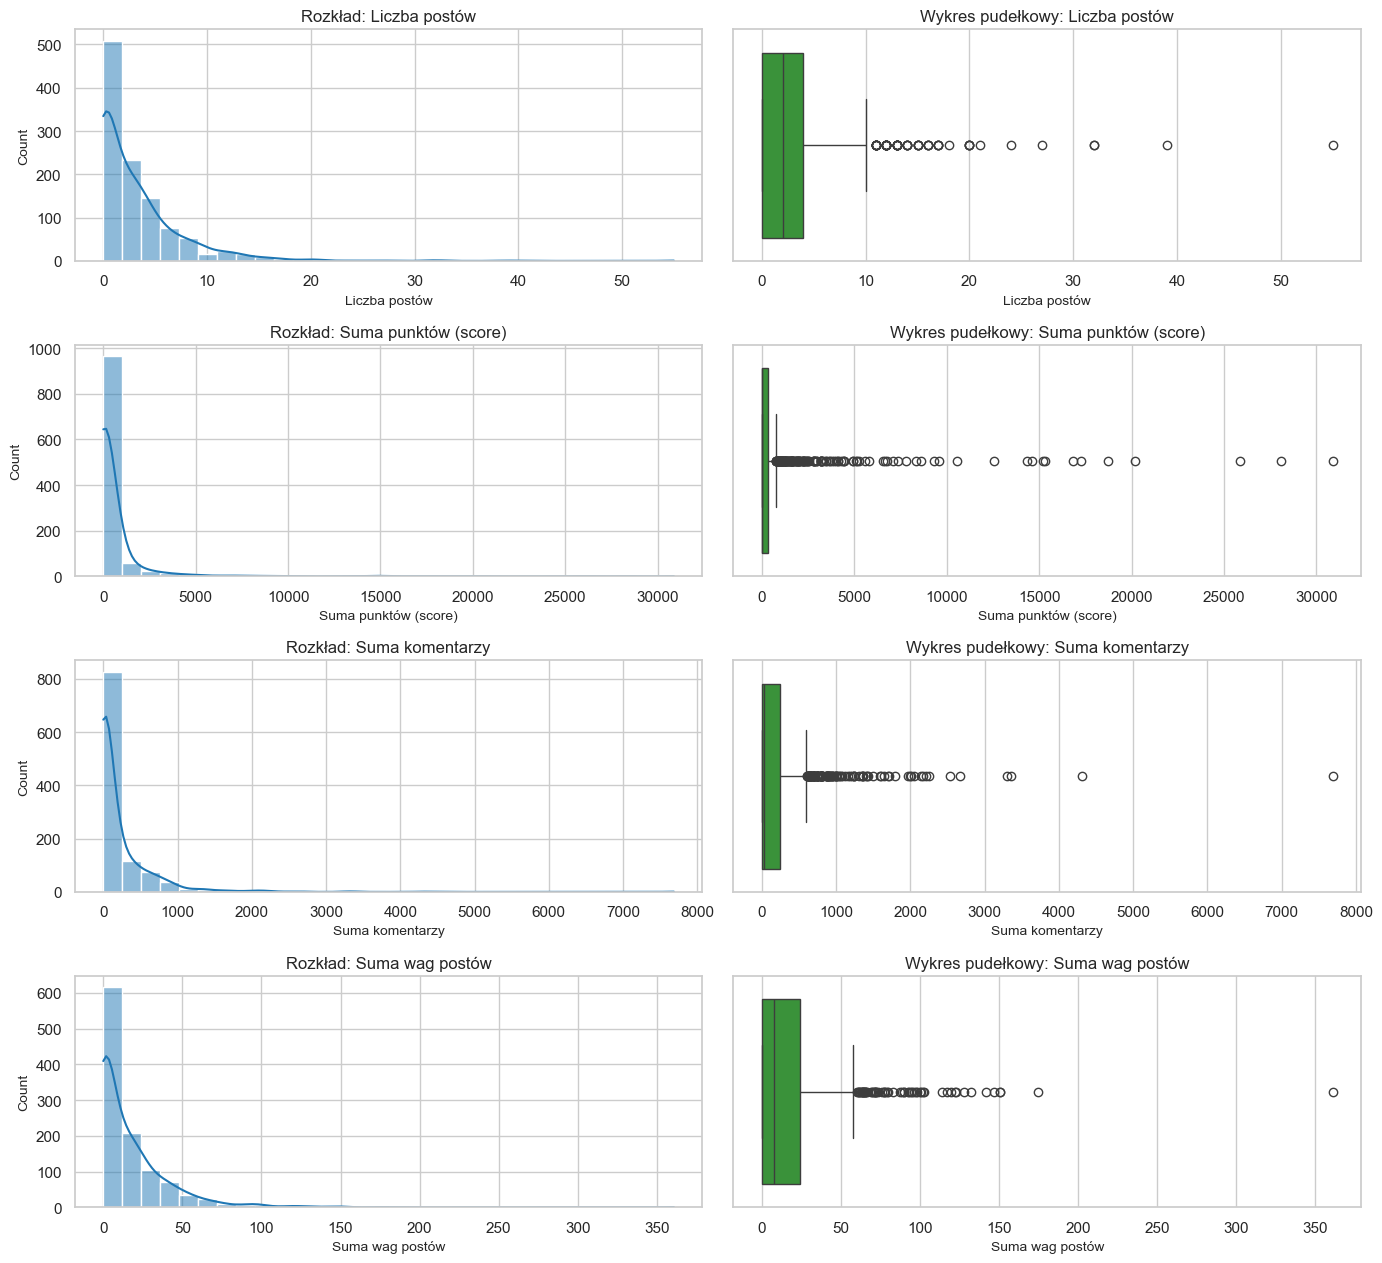

In [8]:
dist_cols = [
    c for c in ["reddit_posts", "reddit_score_sum", "reddit_comments_sum", "reddit_weight_sum"] if c in df.columns
]

if len(dist_cols) > 0:
    n = len(dist_cols)
    fig, axes = plt.subplots(n, 2, figsize=(14, 3.2 * n))
    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(dist_cols):
        display_name = label_map.get(col, col)
        sns.histplot(df[col], bins=30, kde=True, ax=axes[i, 0], color="tab:blue")
        axes[i, 0].set_title(f"Rozkład: {display_name}")
        axes[i, 0].set_xlabel(display_name)

        sns.boxplot(x=df[col], ax=axes[i, 1], color="tab:green")
        axes[i, 1].set_title(f"Wykres pudełkowy: {display_name}")
        axes[i, 1].set_xlabel(display_name)

    plt.tight_layout()
    plt.show()


Średnie metryki aktywności według dnia tygodnia:


,reddit_posts,reddit_weight_sum,reddit_score_sum,reddit_comments_sum
weekday,,,,
Poniedziałek,6.465,36.485,1530.994,488.726
Wtorek,4.350,23.024,631.815,265.771
Środa,3.596,19.616,695.917,243.365
Czwartek,3.705,19.784,988.769,268.006
Piątek,3.647,19.843,510.397,222.788
Sobota,0.000,0.000,0.000,0.000
Niedziela,0.000,0.000,0.000,0.000


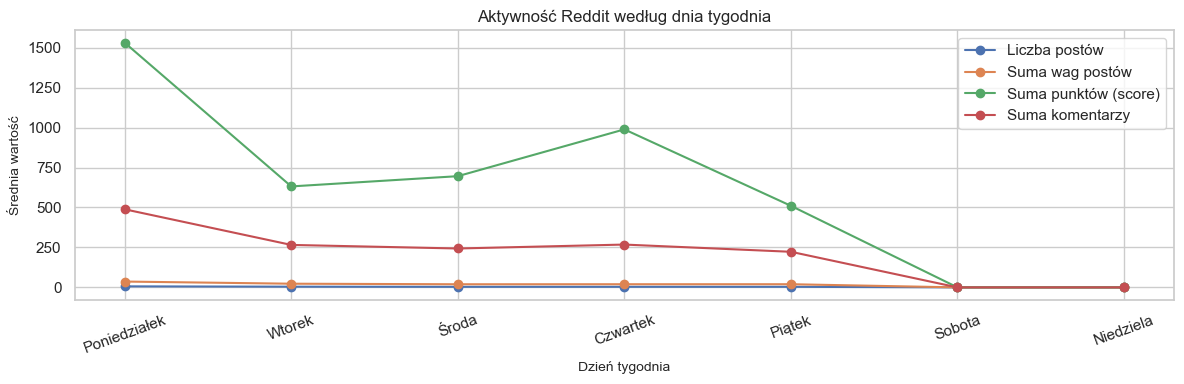

Średnie metryki sentymentu (dni aktywne) według dnia tygodnia:


,reddit_vader_mean,reddit_finbert_mean,reddit_vader_weighted_mean,reddit_finbert_weighted_mean,reddit_sent_mean
weekday,,,,,
Poniedziałek,0.3604,-0.1526,0.4175,-0.1814,0.3604
Wtorek,0.3890,-0.1699,0.4528,-0.2021,0.3890
Środa,0.4307,-0.0884,0.4649,-0.1101,0.4307
Czwartek,0.3559,-0.0951,0.3970,-0.1245,0.3559
Piątek,0.2879,-0.1800,0.3030,-0.2165,0.2879
Sobota,NaN,NaN,NaN,NaN,NaN
Niedziela,NaN,NaN,NaN,NaN,NaN


In [9]:
weekday_map = {
    "Monday": "Poniedziałek",
    "Tuesday": "Wtorek",
    "Wednesday": "Środa",
    "Thursday": "Czwartek",
    "Friday": "Piątek",
    "Saturday": "Sobota",
    "Sunday": "Niedziela",
}
weekday_order = ["Poniedziałek", "Wtorek", "Środa", "Czwartek", "Piątek", "Sobota", "Niedziela"]

df["weekday"] = df["date"].dt.day_name().map(weekday_map)

if len(activity_cols) > 0:
    weekday_activity = (
        df.groupby("weekday")[activity_cols]
        .mean()
        .reindex(weekday_order)
        .round(3)
    )
    print("Średnie metryki aktywności według dnia tygodnia:")
    display(weekday_activity)

    plt.figure(figsize=(12, 4))
    for col in activity_cols:
        plt.plot(weekday_activity.index, weekday_activity[col], marker="o", label=label_map.get(col, col))
    plt.title("Aktywność Reddit według dnia tygodnia")
    plt.xlabel("Dzień tygodnia")
    plt.ylabel("Średnia wartość")
    plt.xticks(rotation=20)
    plt.legend()
    plt.tight_layout()
    plt.show()

if len(sentiment_trend_cols) > 0:
    weekday_sentiment = (
        df.loc[active_mask]
        .groupby("weekday")[sentiment_trend_cols]
        .mean()
        .reindex(weekday_order)
        .round(4)
    )
    print("Średnie metryki sentymentu (dni aktywne) według dnia tygodnia:")
    display(weekday_sentiment)


Ostatnie 12 miesięcy: średnie miesięczne


,reddit_posts,reddit_weight_sum,reddit_score_sum,reddit_comments_sum,reddit_vader_mean,reddit_finbert_mean,reddit_vader_weighted_mean,reddit_finbert_weighted_mean,reddit_sent_mean
date,,,,,,,,,
2025-01-31,3.2903,16.8684,492.4194,190.3871,0.4857,-0.1133,0.5393,-0.1885,0.4857
2025-02-28,5.2500,29.3929,1747.6786,432.7143,0.1939,-0.2382,0.2727,-0.3100,0.1939
2025-03-31,12.7419,70.1533,6001.7097,1082.0968,0.0819,-0.3162,0.0958,-0.4196,0.0819
2025-04-30,6.7000,42.5575,3052.5667,623.1667,0.0958,-0.3379,0.0670,-0.4094,0.0958
2025-05-31,4.0323,24.7982,1160.8065,289.6129,0.3911,-0.0878,0.3781,-0.1568,0.3911
2025-06-30,5.0333,29.4785,994.4333,318.7000,0.3843,-0.2084,0.3768,-0.2744,0.3843
2025-07-31,4.5161,25.7890,371.1613,198.1613,0.3254,-0.2145,0.3497,-0.2681,0.3254
2025-08-31,1.8065,9.0682,219.0000,63.4839,0.1842,-0.2251,0.2472,-0.2412,0.1842
2025-09-30,2.8333,16.2197,412.2000,154.4333,0.3683,-0.0333,0.3436,-0.1005,0.3683


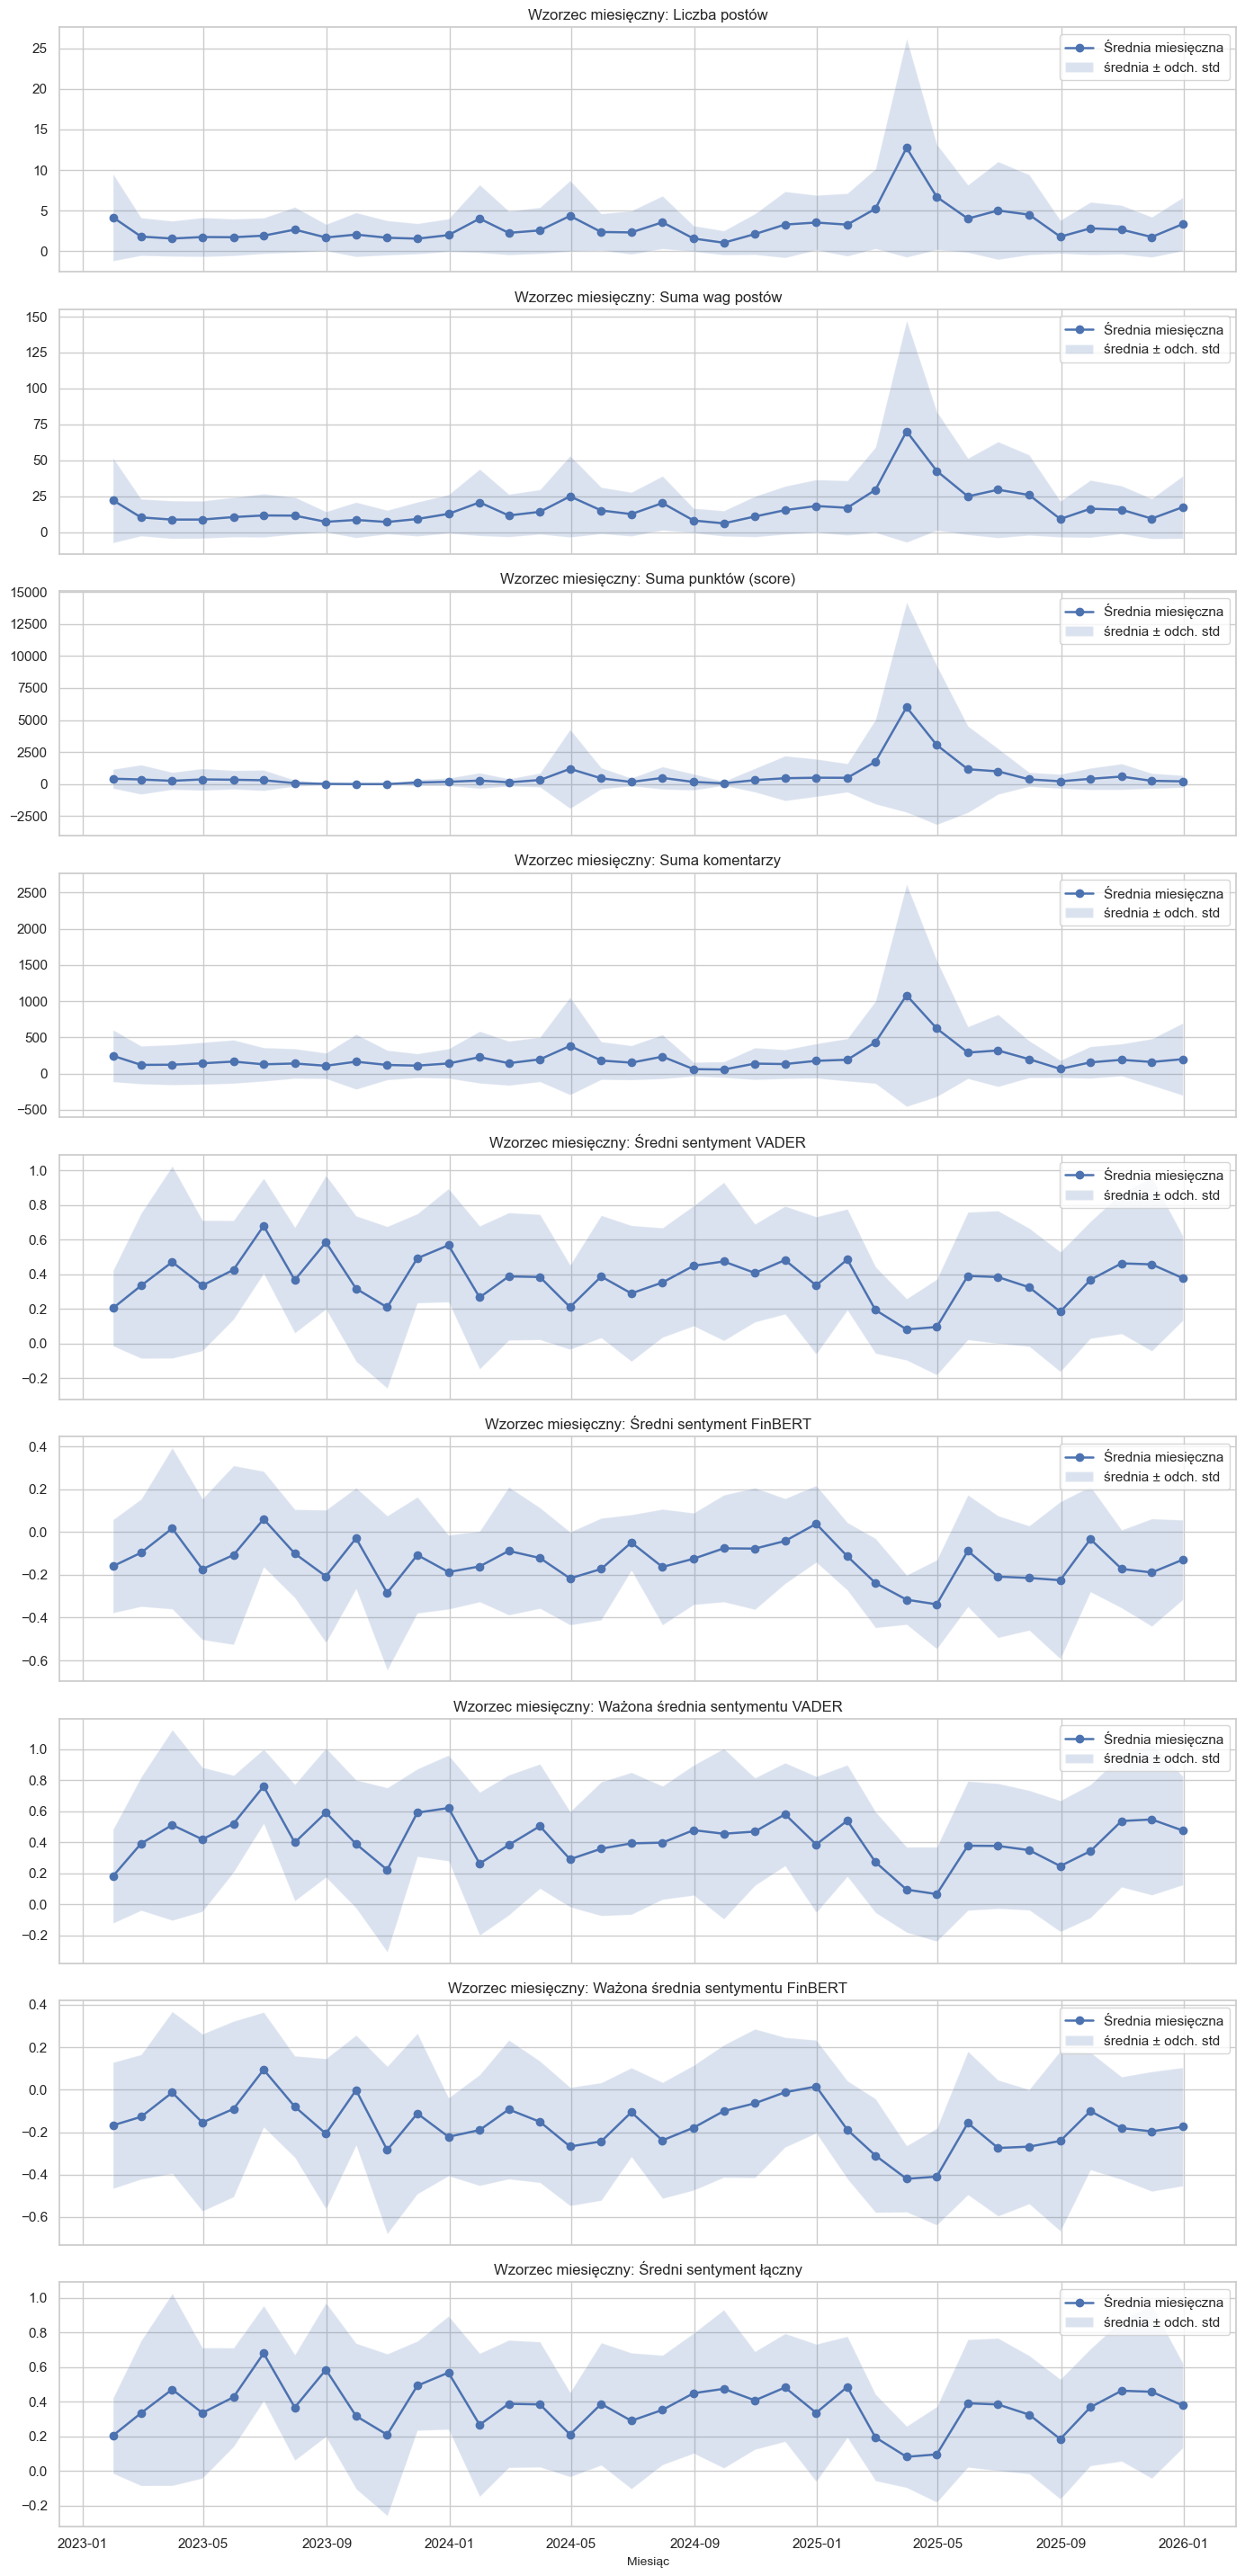

In [10]:
monthly_cols = unique_order(activity_cols + sentiment_trend_cols)

if len(monthly_cols) > 0:
    monthly_mean = df.set_index("date")[monthly_cols].resample("ME").mean()
    monthly_std = df.set_index("date")[monthly_cols].resample("ME").std()

    print("Ostatnie 12 miesięcy: średnie miesięczne")
    display(monthly_mean.tail(12).round(4))

    n = len(monthly_cols)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.2 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for i, col in enumerate(monthly_cols):
        ax = axes[i]
        display_name = label_map.get(col, col)
        ax.plot(monthly_mean.index, monthly_mean[col], marker="o", linewidth=1.8, label="Średnia miesięczna")
        lower = monthly_mean[col] - monthly_std[col].fillna(0)
        upper = monthly_mean[col] + monthly_std[col].fillna(0)
        ax.fill_between(monthly_mean.index, lower, upper, alpha=0.2, label="średnia ± odch. std")
        ax.set_title(f"Wzorzec miesięczny: {display_name}")
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Miesiąc")
    plt.tight_layout()
    plt.show()


,reddit_posts,reddit_score_sum,reddit_comments_sum,reddit_vader_mean,reddit_finbert_mean,reddit_sent_mean
opóźnienie,,,,,,
1,0.2525,0.1799,0.1669,0.0935,0.1245,0.0935
2,0.0773,0.1894,0.0948,-0.0222,-0.0196,-0.0222
3,0.1546,0.2304,0.1255,-0.1034,0.0381,-0.1034
4,0.2143,0.2002,0.1129,-0.0905,0.0774,-0.0905
5,0.0744,0.1295,0.0679,-0.0207,0.0072,-0.0207
6,0.2349,0.1152,0.0786,0.1241,0.0387,0.1241
7,0.5300,0.4251,0.3314,0.2106,0.1392,0.2106
8,0.2002,0.1277,0.1126,0.0968,0.0415,0.0968
9,0.0754,0.1419,0.0770,-0.0174,-0.0024,-0.0174


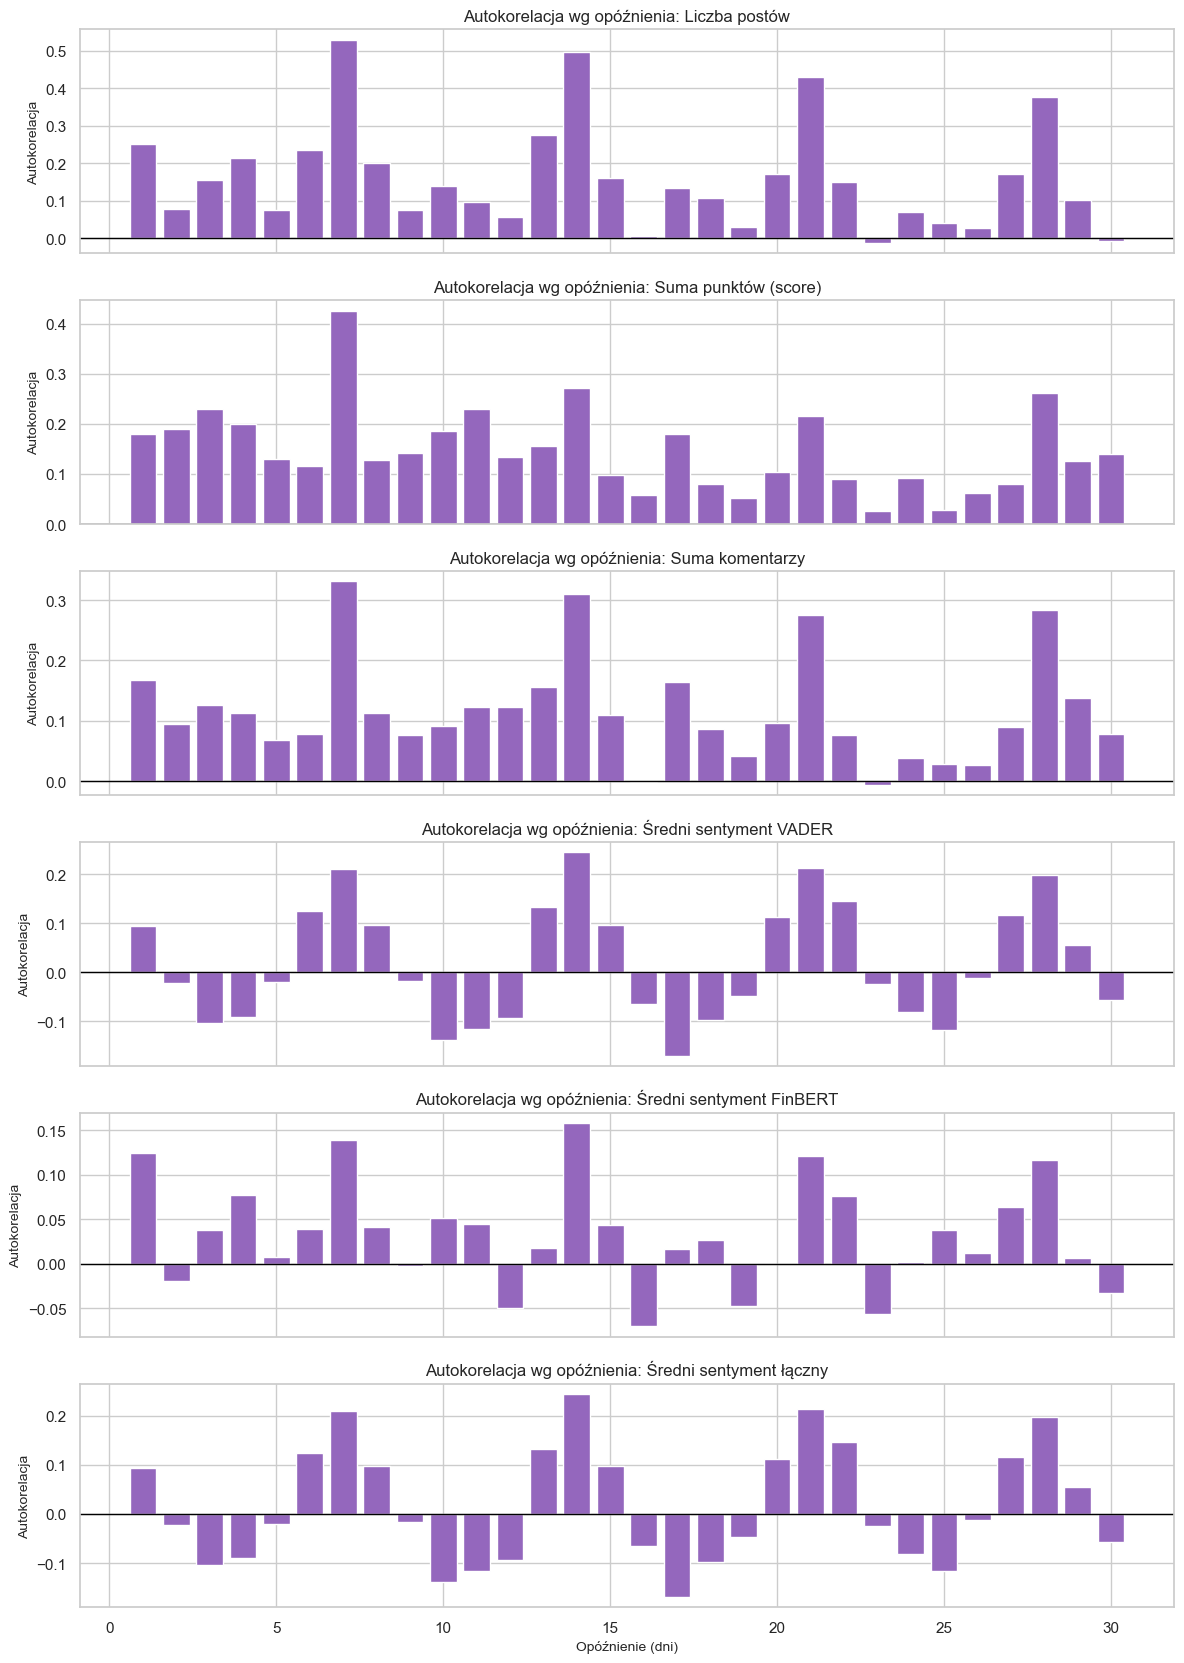

Podsumowanie pierwszych różnic:


,count,mean,std,min,25%,50%,75%,max
reddit_posts,1094.0,0.0018,5.4514,-39.0000,-2.0000,0.0000,2.0000,55.0000
reddit_weight_sum,1094.0,0.0061,31.8838,-304.3643,-12.6639,0.0000,11.0236,360.7635
reddit_score_sum,1094.0,0.0018,2979.4748,-30688.0000,-83.7500,0.0000,87.7500,30877.0000
reddit_comments_sum,1094.0,0.0229,591.5543,-7034.0000,-136.7500,0.0000,120.5000,7685.0000
reddit_vader_mean,479.0,-0.0140,0.5018,-1.5709,-0.3397,-0.0060,0.2808,1.8712
reddit_finbert_mean,479.0,-0.0060,0.3425,-1.0979,-0.2173,0.0001,0.1763,1.0801
reddit_vader_weighted_mean,479.0,-0.0215,0.5687,-1.5725,-0.4028,0.0059,0.3182,1.8645
reddit_finbert_weighted_mean,479.0,-0.0052,0.4026,-1.0162,-0.2456,-0.0011,0.2429,1.2496
reddit_sent_mean,479.0,-0.0140,0.5018,-1.5709,-0.3397,-0.0060,0.2808,1.8712


In [11]:
autocorr_cols = [
    c
    for c in [
        "reddit_posts",
        "reddit_score_sum",
        "reddit_comments_sum",
        "reddit_vader_mean",
        "reddit_finbert_mean",
        "reddit_sent_mean",
    ]
    if c in df.columns
]

max_lag = 30
if len(autocorr_cols) > 0:
    autocorr_table = pd.DataFrame(
        {
            col: [df[col].fillna(0).autocorr(lag=lag) for lag in range(1, max_lag + 1)]
            for col in autocorr_cols
        },
        index=range(1, max_lag + 1),
    )
    autocorr_table.index.name = "opóźnienie"
    display(autocorr_table.head(10).round(4))

    n = len(autocorr_cols)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.8 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for i, col in enumerate(autocorr_cols):
        ax = axes[i]
        display_name = label_map.get(col, col)
        ax.bar(autocorr_table.index, autocorr_table[col], color="tab:purple")
        ax.axhline(0, color="black", linewidth=1)
        ax.set_title(f"Autokorelacja wg opóźnienia: {display_name}")
        ax.set_ylabel("Autokorelacja")

    axes[-1].set_xlabel("Opóźnienie (dni)")
    plt.tight_layout()
    plt.show()

    diff_cols = unique_order(activity_cols + sentiment_trend_cols)
    if len(diff_cols) > 0:
        diff_summary = df[diff_cols].diff().describe().T.round(4)
        print("Podsumowanie pierwszych różnic:")
        display(diff_summary)


## Lista kontrolna interpretacji (wstępnej)

Po uruchomieniu wszystkich komórek podsumuj:
- czy szereg jest kompletny (ciągłość dat) i czy nie ma duplikatów,
- jaki jest udział dni bez aktywności (`reddit_posts = 0`) i jak wpływa to na metryki sentymentu,
- które metryki aktywności mają największą zmienność i wartości odstające,
- czy metryki `reddit_sent_*` są de facto pochodne od `reddit_vader_*` (ryzyko podwójnego sygnału),
- czy występuje sezonowość tygodniowa/miesięczna,
- czy autokorelacja sugeruje użyteczne opóźnienia dla modelu.

W modelowaniu traktuj metryki pochodne ostrożnie i unikaj jednoczesnego użycia silnie redundatnych cech bez uzasadnienia.
